In [1]:
import ROOT
import numpy as np
import uproot as ur
import awkward as ak
import matplotlib.pyplot as plt
import mplhep as hep
import os
hep.style.use("CMS")
hep.style.use(hep.style.CMS)
import matplotlib.colors as mcolors
from matplotlib import colormaps
from scipy.optimize import curve_fit
import pandas as pd
from cycler import cycler
plt.rcParams["axes.prop_cycle"] = cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

In [2]:
def OpenCorrections(file):
    df = pd.read_csv(file, sep = '\s+')
    return df

In [3]:
corrections_dict = {"C":OpenCorrections("/media/miguel/Elements_2024/CLAS_data/C/radiative_corrections/clasC12_geometric.out"), "LD2":OpenCorrections("/media/miguel/Elements_2024/CLAS_data/C/radiative_corrections/clasd2_geometric.out")}

In [6]:
num_Q2_bins = 9*5
num_x_bins= 10*5
Q2_bin_edges = np.logspace(np.log10(1), np.log10(11), num=num_Q2_bins+1, base=10.)
x_bin_edges = np.linspace(0, .8, num=num_x_bins+1)
x_bin_centers = (x_bin_edges[:-1] + x_bin_edges[1:])/2
Q2_bin_centers = (Q2_bin_edges[:-1] + Q2_bin_edges[1:])/2

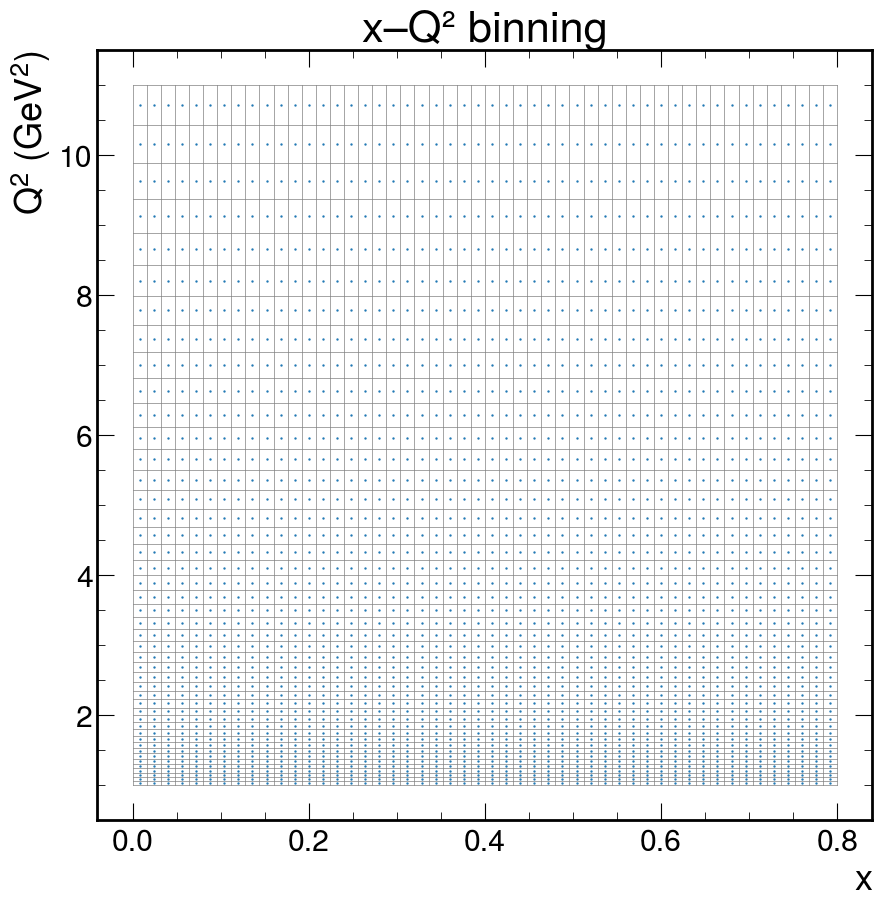

In [69]:
# Make a grid of edges
for x in x_bin_edges:
    plt.plot([x, x], [Q2_bin_edges[0], Q2_bin_edges[-1]], color="gray", lw=0.5)

for Q2 in Q2_bin_edges:
    plt.plot([x_bin_edges[0], x_bin_edges[-1]], [Q2, Q2], color="gray", lw=0.5)

# plt.xlim(0, 0.8)
# plt.ylim(1, 11)
# plt.yscale("log")   # Q2 bins are log-spaced
plt.xlabel("x")
plt.ylabel("$Q^2~(GeV^2)$")
plt.title("x–Q² binning")
plt.scatter(x_padded.flatten(), Q2_padded.flatten(), s =  .5)
plt.show()

In [7]:
corrections_dict["C"]["x_bin_center"] = x_bin_centers[np.digitize(corrections_dict["C"]["x"], x_bin_edges)-1]
corrections_dict["C"]["Q2_bin_center"] = Q2_bin_centers[np.digitize(corrections_dict["C"]["Q2"], Q2_bin_edges)-1]
corrections_dict["LD2"]["x_bin_center"] = x_bin_centers[np.digitize(corrections_dict["LD2"]["x"], x_bin_edges)-1]
corrections_dict["LD2"]["Q2_bin_center"] = Q2_bin_centers[np.digitize(corrections_dict["LD2"]["Q2"], Q2_bin_edges)-1]

In [31]:
Q2_binning = np.arange(1, 12, 1)
x_padded, Q2_padded = np.meshgrid(x_bin_centers, Q2_bin_centers)
# Taking transpose gives x constant along inner dimension, Q2 varies along inner dimension
x_padded = x_padded.T
Q2_padded = Q2_padded.T

In [35]:
def Q2_calculation_from_y(y_val, x_values):
    Eb = 10.547
    Mp = 0.938272
    return 2*Mp*Eb*y_val*np.asarray(x_values)
def y_calculation_from_Q2_x(x_values, Q2_values):
    Eb = 10.547
    Mp = 0.938272
    return np.asarray(Q2_values)/(np.asarray(x_values)*2*Mp*Eb)

In [84]:
Eb =  10.5473
Mp = 0.938272
y = y_calculation_from_Q2_x(x_padded.flatten(), Q2_padded.flatten())
Ep = Eb*(1-y)

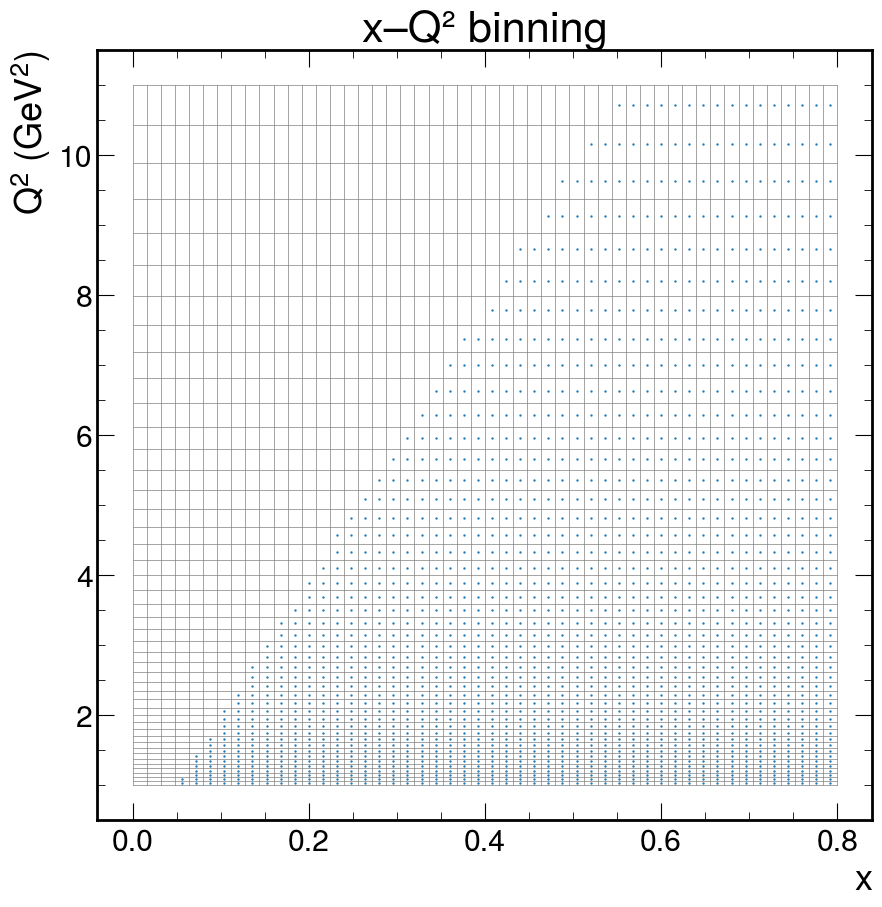

In [79]:
# Make a grid of edges
for x in x_bin_edges:
    plt.plot([x, x], [Q2_bin_edges[0], Q2_bin_edges[-1]], color="gray", lw=0.5)

for Q2 in Q2_bin_edges:
    plt.plot([x_bin_edges[0], x_bin_edges[-1]], [Q2, Q2], color="gray", lw=0.5)

# plt.xlim(0, 0.8)
# plt.ylim(1, 11)
# plt.yscale("log")   # Q2 bins are log-spaced
plt.xlabel("x")
plt.ylabel("$Q^2~(GeV^2)$")
plt.title("x–Q² binning")
plt.scatter(x_padded.flatten()[mask], Q2_padded.flatten()[mask], s =  .5)
plt.show()

(array([13., 21., 28., 34., 32., 34., 35., 36., 34., 32., 32., 32., 32.,
        32., 28., 30., 30., 29., 25., 25., 27., 24., 25., 27., 20., 24.,
        22., 21., 21., 21., 20., 20., 20., 22., 18., 18., 18., 19., 16.,
        17., 18., 17., 18., 13., 17., 15., 15., 15., 14., 15., 15., 14.,
        15., 14., 14., 11., 15., 12., 13., 12., 14., 13., 11., 12., 11.,
        12., 11., 13.,  9., 12., 10., 11., 10., 11., 11.,  7., 11.,  8.,
         8.,  8.,  9.,  7., 10.,  6.,  9.,  6.,  7.,  8.,  6.,  8.,  6.,
         6.,  9.,  4.,  7.,  5.,  8.,  5.,  5.,  9.]),
 array([0.06554088, 0.0748637 , 0.08418652, 0.09350934, 0.10283216,
        0.11215498, 0.12147781, 0.13080063, 0.14012345, 0.14944627,
        0.15876909, 0.16809191, 0.17741473, 0.18673755, 0.19606037,
        0.20538319, 0.21470601, 0.22402883, 0.23335165, 0.24267447,
        0.2519973 , 0.26132012, 0.27064294, 0.27996576, 0.28928858,
        0.2986114 , 0.30793422, 0.31725704, 0.32657986, 0.33590268,
        0.3452255 , 0.3545

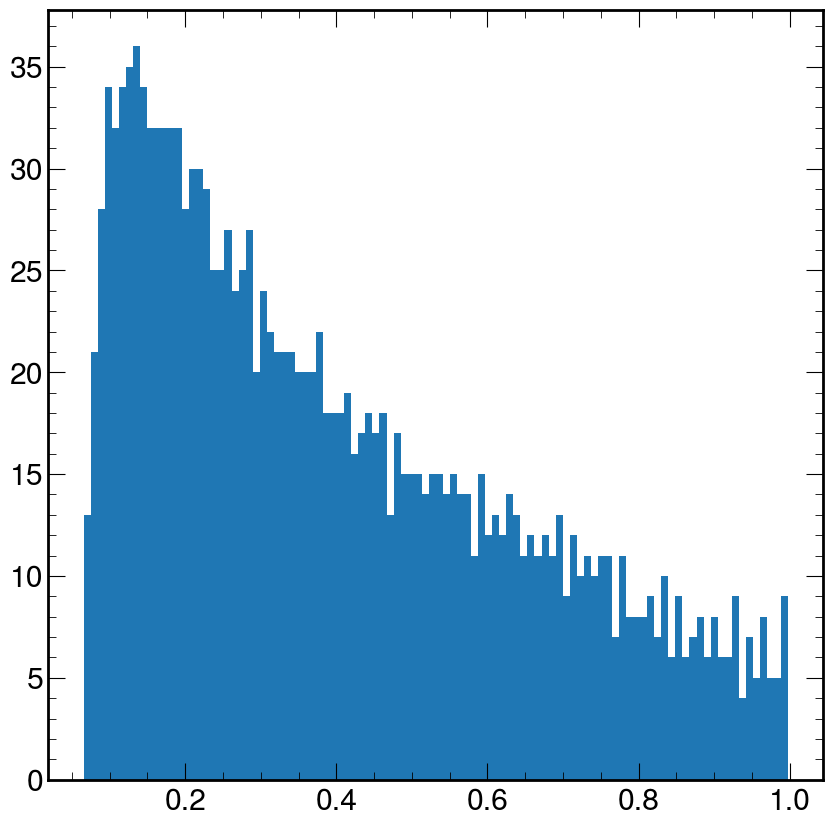

In [74]:
mask = (Ep>0)
plt.hist(y[mask], bins=100)

(0.0, 1.3)

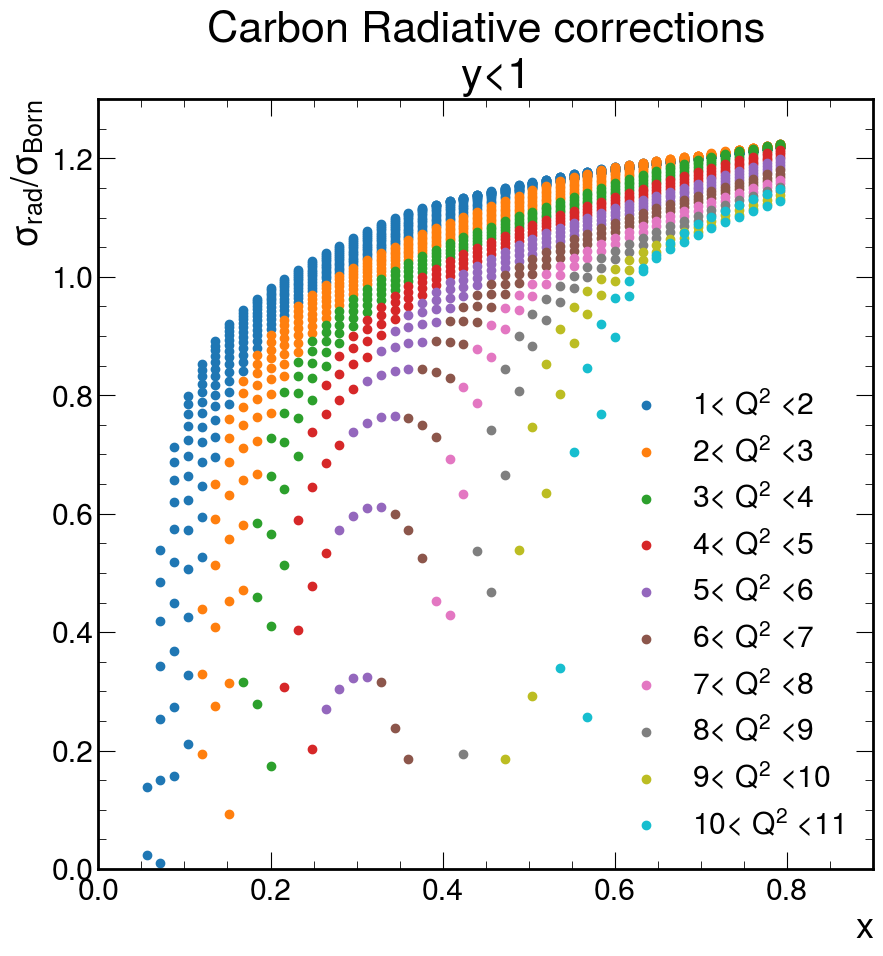

In [80]:
for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])
    
    corrections = corrections_dict["C"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]}")
    y = y_calculation_from_Q2_x(corrections["x_bin_center"], corrections["Q2_bin_center"])
    y_mask = y < 1
    
    plt.scatter(corrections["x_bin_center"][y_mask], corrections["Sig_Born"][y_mask]/corrections["Sig_Rad"][y_mask], label=f"{round(Q2_range[0],2)}< $Q^2$ <{round(Q2_range[1],2)}")
plt.legend()
plt.xlabel("x")
plt.ylabel("$\sigma_{rad}/\sigma_{Born}$")
plt.title("Carbon Radiative corrections\n $y\less1$")
plt.xlim(0, .9)
plt.ylim(0, 1.3)

(0.0, 1.3)

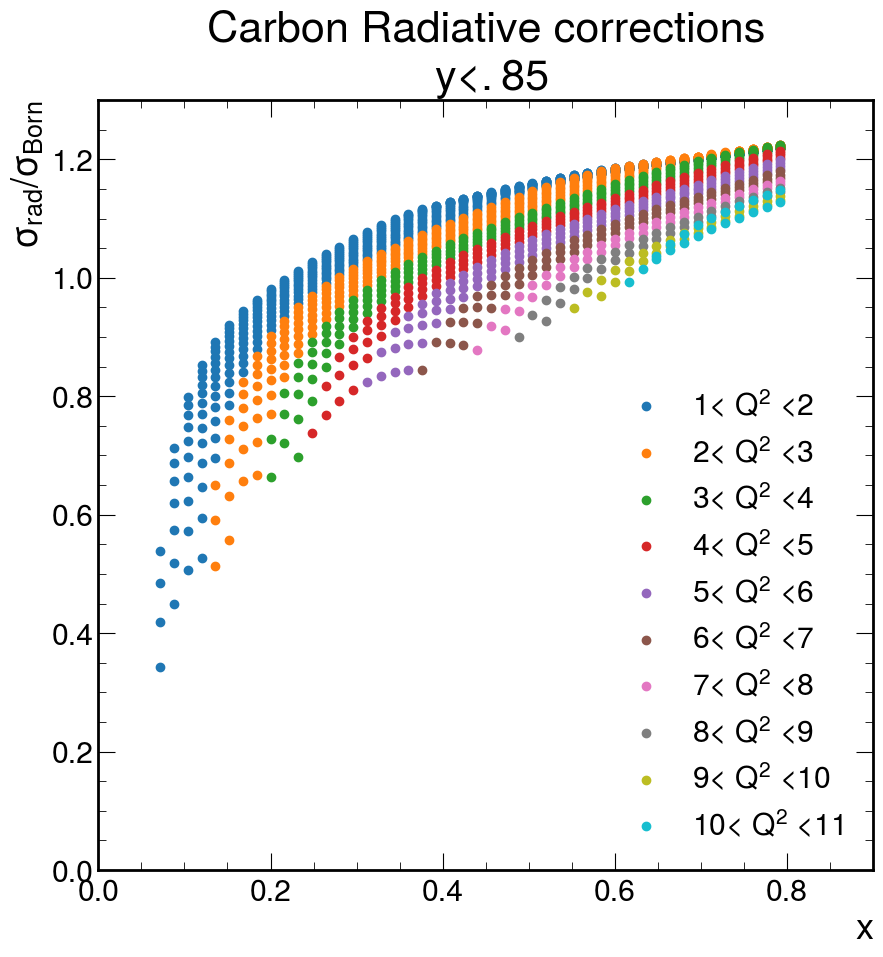

In [62]:
for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])
    
    corrections = corrections_dict["C"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]}")
    y = y_calculation_from_Q2_x(corrections["x_bin_center"], corrections["Q2_bin_center"])
    y_mask = y < .85
    plt.scatter(corrections["x_bin_center"][y_mask], corrections["Sig_Born"][y_mask]/corrections["Sig_Rad"][y_mask], label=f"{round(Q2_range[0],2)}< $Q^2$ <{round(Q2_range[1],2)}")
plt.legend()
plt.xlabel("x")
plt.ylabel("$\sigma_{rad}/\sigma_{Born}$")
plt.title("Carbon Radiative corrections\n $y\less.85$")
plt.xlim(0, .9)
plt.ylim(0, 1.3)

(0.0, 1.3)

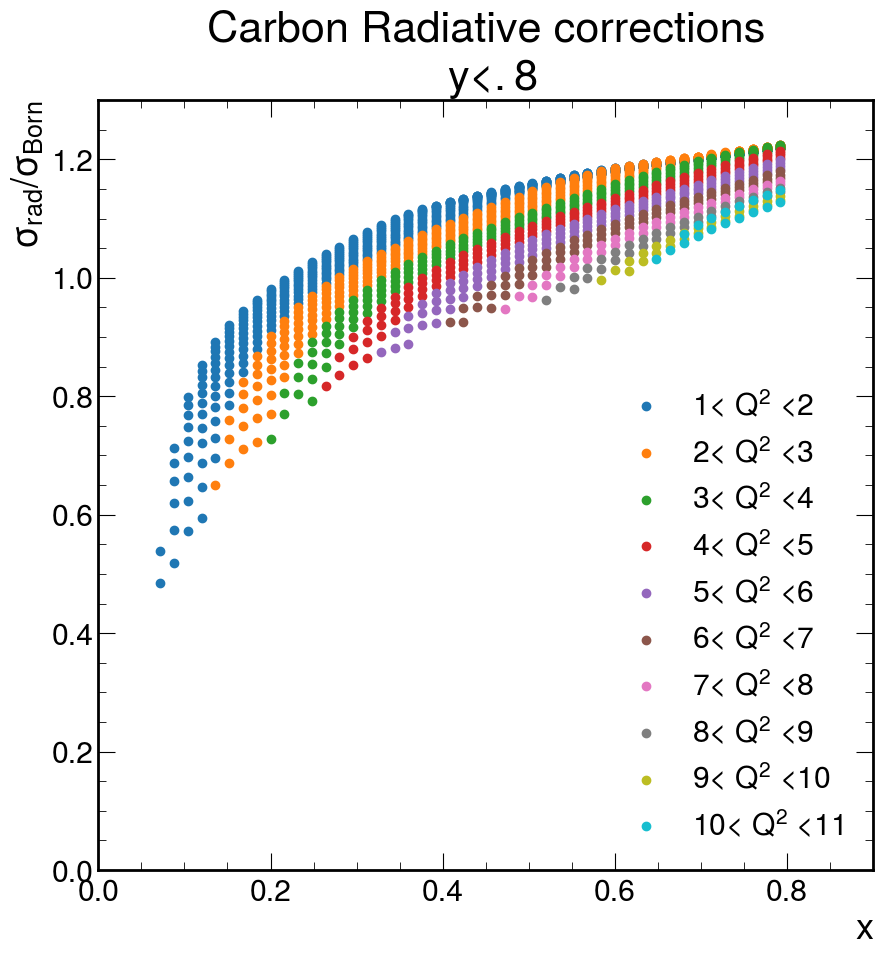

In [61]:
for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])
    
    corrections = corrections_dict["C"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]}")
    y = y_calculation_from_Q2_x(corrections["x_bin_center"], corrections["Q2_bin_center"])
    y_mask = y < .8
    plt.scatter(corrections["x_bin_center"][y_mask], corrections["Sig_Born"][y_mask]/corrections["Sig_Rad"][y_mask], label=f"{round(Q2_range[0],2)}< $Q^2$ <{round(Q2_range[1],2)}")
plt.legend()
plt.xlabel("x")
plt.ylabel("$\sigma_{rad}/\sigma_{Born}$")
plt.title("Carbon Radiative corrections\n $y\less.8$")
plt.xlim(0, .9)
plt.ylim(0, 1.3)

(0.0, 1.3)

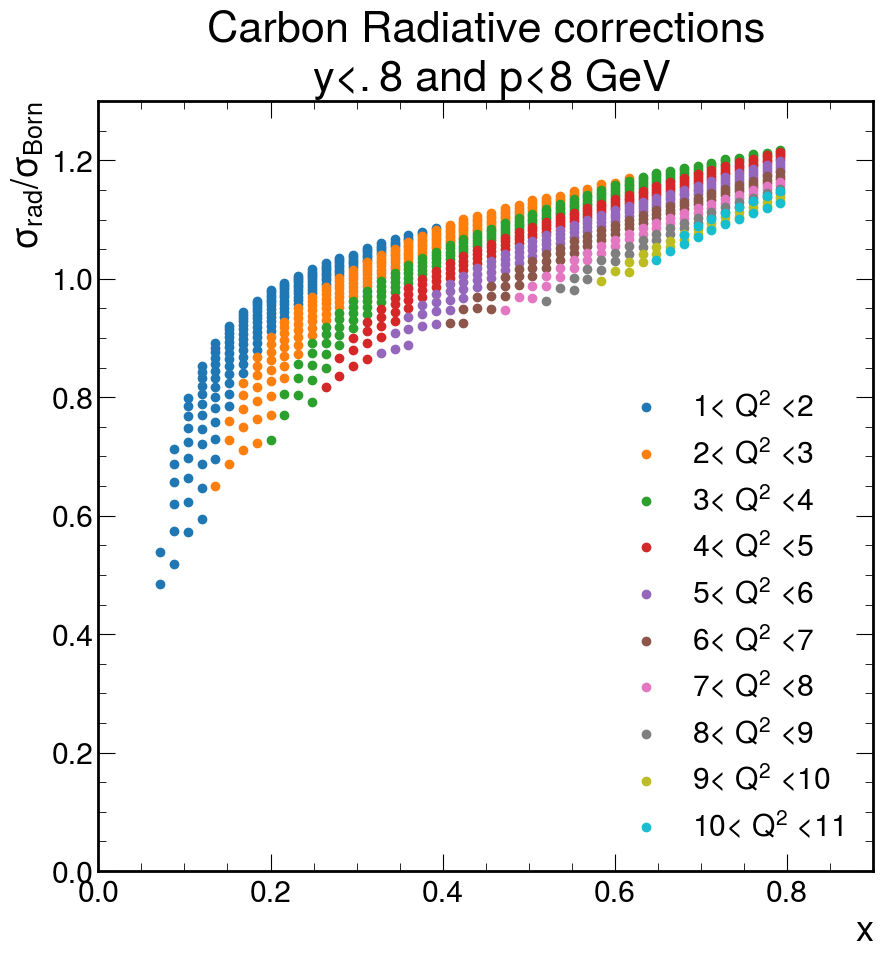

In [93]:
for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])
    
    corrections = corrections_dict["C"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]}")
    y = y_calculation_from_Q2_x(corrections["x_bin_center"], corrections["Q2_bin_center"])
    Ep = Eb*(1-y)
    y_mask = (y < .8) & (Ep<8)
    plt.scatter(corrections["x_bin_center"][y_mask], corrections["Sig_Born"][y_mask]/corrections["Sig_Rad"][y_mask], label=f"{round(Q2_range[0],2)}< $Q^2$ <{round(Q2_range[1],2)}")
plt.legend()
plt.xlabel("x")
plt.ylabel("$\sigma_{rad}/\sigma_{Born}$")
plt.title("Carbon Radiative corrections\n $y\less.8$ and p<8 GeV")
plt.xlim(0, .9)
plt.ylim(0, 1.3)

(0.0, 1.3)

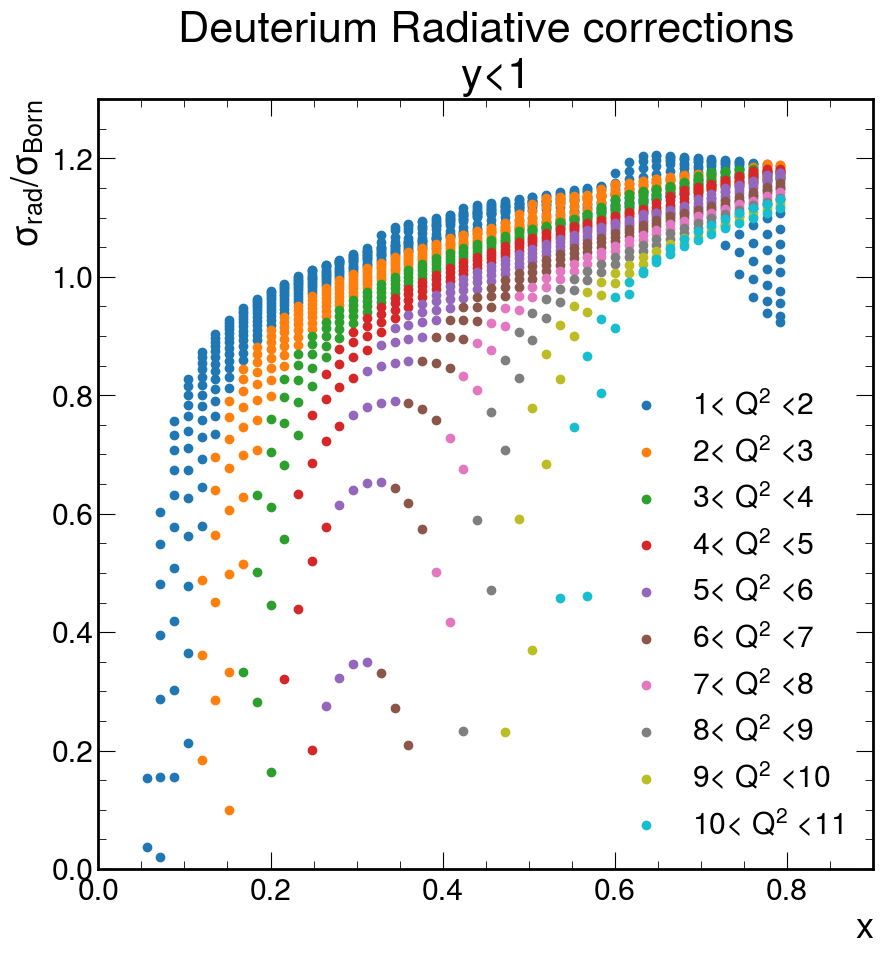

In [82]:
for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])
    
    corrections = corrections_dict["LD2"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]}")
    y = y_calculation_from_Q2_x(corrections["x_bin_center"], corrections["Q2_bin_center"])
    y_mask = y < 1
    plt.scatter(corrections["x_bin_center"][y_mask], corrections["Sig_Born"][y_mask]/corrections["Sig_Rad"][y_mask], label=f"{round(Q2_range[0],2)}< $Q^2$ <{round(Q2_range[1],2)}")
plt.legend()
plt.xlabel("x")
plt.ylabel("$\sigma_{rad}/\sigma_{Born}$")
plt.title("Deuterium Radiative corrections\n $y\less1$")
plt.xlim(0, .9)
plt.ylim(0, 1.3)

(0.0, 1.3)

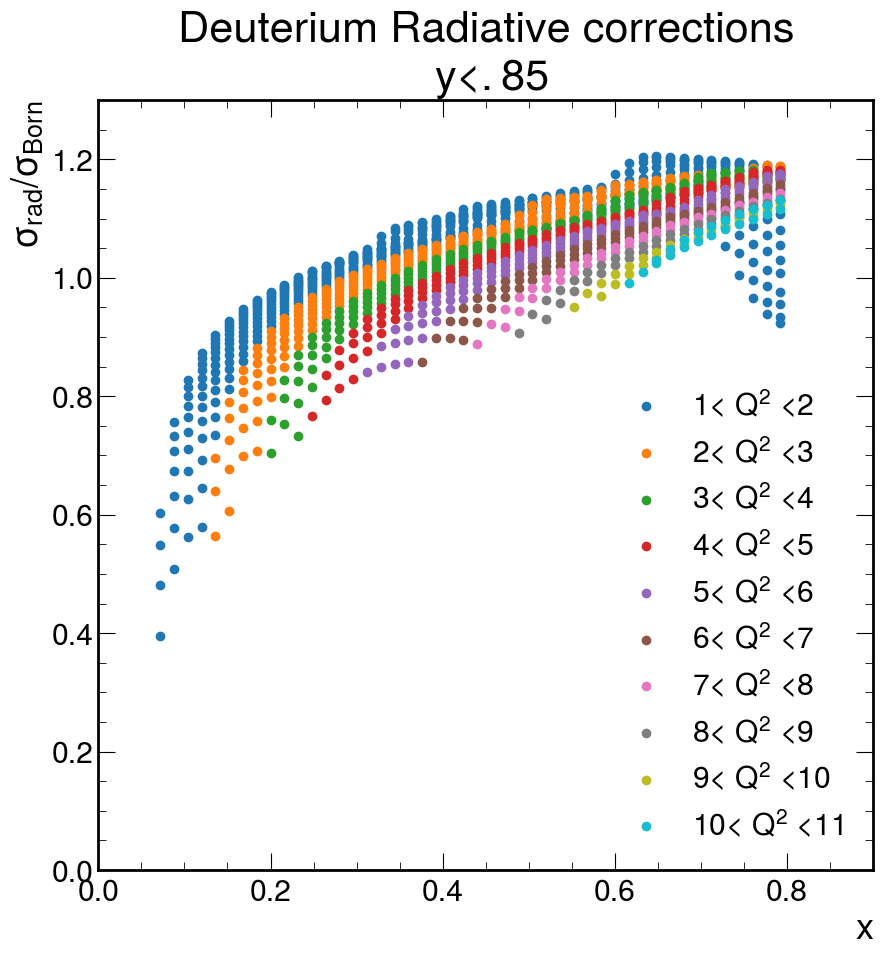

In [63]:
for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])
    
    corrections = corrections_dict["LD2"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]}")
    y = y_calculation_from_Q2_x(corrections["x_bin_center"], corrections["Q2_bin_center"])
    y_mask = y < .85
    plt.scatter(corrections["x_bin_center"][y_mask], corrections["Sig_Born"][y_mask]/corrections["Sig_Rad"][y_mask], label=f"{round(Q2_range[0],2)}< $Q^2$ <{round(Q2_range[1],2)}")
plt.legend()
plt.xlabel("x")
plt.ylabel("$\sigma_{rad}/\sigma_{Born}$")
plt.title("Deuterium Radiative corrections\n $y\less.85$")
plt.xlim(0, .9)
plt.ylim(0, 1.3)

(0.0, 1.3)

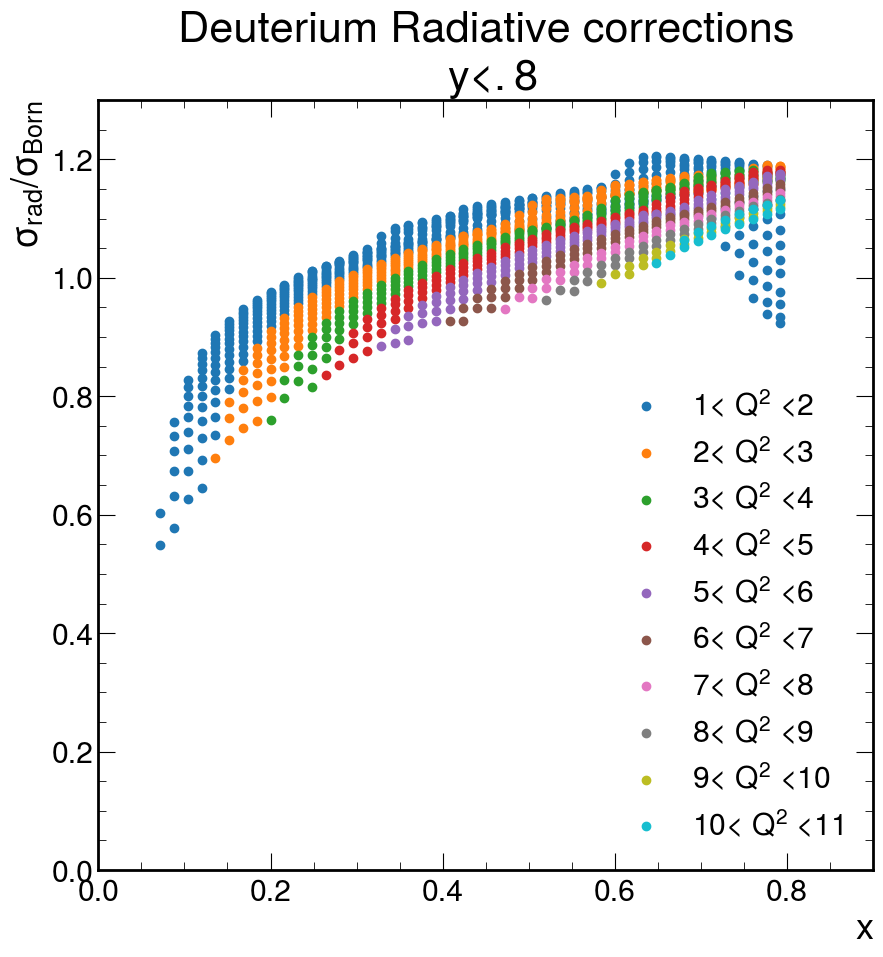

In [90]:
for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])
    
    corrections = corrections_dict["LD2"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]}")
    y = y_calculation_from_Q2_x(corrections["x_bin_center"], corrections["Q2_bin_center"])
    Ep = Eb*(1-y)
    y_mask = (y < .8) 
    plt.scatter(corrections["x_bin_center"][y_mask], corrections["Sig_Born"][y_mask]/corrections["Sig_Rad"][y_mask], label=f"{round(Q2_range[0],2)}< $Q^2$ <{round(Q2_range[1],2)}")
plt.legend()
plt.xlabel("x")
plt.ylabel("$\sigma_{rad}/\sigma_{Born}$")
plt.title("Deuterium Radiative corrections\n $y\less.8$")
plt.xlim(0, .9)
plt.ylim(0, 1.3)

(0.0, 1.3)

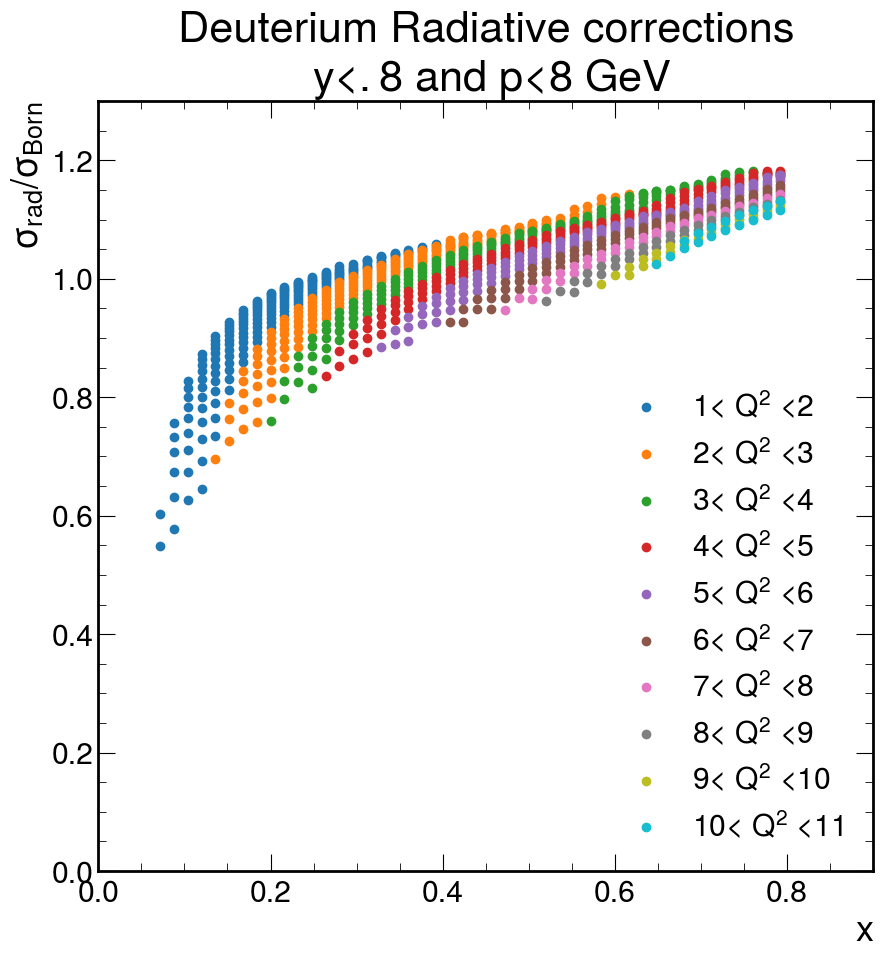

In [92]:
for i, Q2_lower_edge in enumerate(Q2_binning):
    if i == len(Q2_binning)-1:
        continue
    Q2_range = (Q2_lower_edge, Q2_binning[i+1])
    
    corrections = corrections_dict["LD2"].query(f"Q2_bin_center>{Q2_range[0]} & Q2_bin_center<{Q2_range[1]}")
    y = y_calculation_from_Q2_x(corrections["x_bin_center"], corrections["Q2_bin_center"])
    Ep = Eb*(1-y)
    y_mask = (y < .8) & (Ep<8)
    plt.scatter(corrections["x_bin_center"][y_mask], corrections["Sig_Born"][y_mask]/corrections["Sig_Rad"][y_mask], label=f"{round(Q2_range[0],2)}< $Q^2$ <{round(Q2_range[1],2)}")
plt.legend()
plt.xlabel("x")
plt.ylabel("$\sigma_{rad}/\sigma_{Born}$")
plt.title("Deuterium Radiative corrections\n $y\less.8$ and p<8 GeV")
plt.xlim(0, .9)
plt.ylim(0, 1.3)